In [32]:
from dfbr.utils.files import get_config
from dfbr.data.dataset import BikeDemandDataset
from dfbr.models.mlp import MLP
from dfbr.eval.simmulation import Sim, create_station_dict, create_event_df
from dfbr.models.bike_rebalance import BikeRebalanceModel
from dfbr.training.train import get_loss_func, train_one_epoch, evaluate
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
from torch.utils.data import DataLoader
from torch.optim import Adam
import torch
import torch.nn.functional as F

In [2]:
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
#Setup
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
#Read config
config = get_config("baseline.yaml")

#Create a dictionary of stations
station_dict = create_station_dict(config["paths"]["stations"], config["paths"]["station_dist_miles"], config["sim"]["start_inv_pct"])
#Sort by id to ensure alignment
station_ids = sorted(station_dict.keys())

#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
#Load Data for Predictive Model
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
#Create datasets
train_ds = BikeDemandDataset(
        file = config["paths"]["input"],
        start_date = config["data"]["train_start_date"],
        end_date = config["data"]["train_end_date"],
        target_cols= [str(id) for id in station_ids],
        input_scale_cols= ['mean_temp', 'precip', 'max_gust'],
        input_no_scale_cols=['sin_day_of_week', 'cos_day_of_week', 'sin_month', 'cos_month']
    )

training_stats = {'mean': train_ds.mean, 'std': train_ds.std, 'y_mean': train_ds.y_mean, 'y_std': train_ds.y_std}

test_ds = BikeDemandDataset(
        file = config["paths"]["input"],
        start_date = config["data"]["test_start_date"],
        end_date = config["data"]["test_end_date"],
        target_cols= [str(id) for id in station_ids],
        input_scale_cols= ['mean_temp', 'precip', 'max_gust'],
        input_no_scale_cols=['sin_day_of_week', 'cos_day_of_week', 'sin_month', 'cos_month'],
        is_train=False,
        scaling_factor=training_stats
    )

#Wrap Data Loaders
train_dl = DataLoader(train_ds, batch_size=config["training"]["batch_size"], shuffle=False)
test_dl = DataLoader(test_ds, batch_size=config["training"]["batch_size"], shuffle=False)

In [3]:
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
#Instantiate Model and Train
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
#Create MLP
input_size = len(train_ds[0][0])
output_size = len(train_ds[0][1])
pred_model = MLP(input_size, output_size, config["model"]["hidden_layers"])

#Create loss function and optimizer
criterion = get_loss_func(config["training"]["loss_function"])
optimizer = Adam(pred_model.parameters(), lr=config["training"]["learning_rate"], weight_decay = config["training"]["weight_decay"])

#Training loop
for epoch in range(config["training"]["epochs"]):
    train_loss = train_one_epoch(pred_model, train_dl, optimizer, criterion, 'cpu')
    test_loss = evaluate(pred_model, test_dl, criterion, 'cpu')
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")


Epoch 1 | Train Loss: 1.0272 | Test Loss: 1.6168
Epoch 2 | Train Loss: 1.0356 | Test Loss: 1.4522
Epoch 3 | Train Loss: 0.9448 | Test Loss: 1.4815
Epoch 4 | Train Loss: 0.9527 | Test Loss: 1.4735
Epoch 5 | Train Loss: 0.9303 | Test Loss: 1.4907
Epoch 6 | Train Loss: 0.9381 | Test Loss: 1.4834
Epoch 7 | Train Loss: 0.9256 | Test Loss: 1.4911
Epoch 8 | Train Loss: 0.9283 | Test Loss: 1.4907
Epoch 9 | Train Loss: 0.9263 | Test Loss: 1.4932
Epoch 10 | Train Loss: 0.9247 | Test Loss: 1.4936
Epoch 11 | Train Loss: 0.9185 | Test Loss: 1.4967
Epoch 12 | Train Loss: 0.9199 | Test Loss: 1.4946
Epoch 13 | Train Loss: 0.9164 | Test Loss: 1.4976
Epoch 14 | Train Loss: 0.9166 | Test Loss: 1.4980
Epoch 15 | Train Loss: 0.9155 | Test Loss: 1.4981
Epoch 16 | Train Loss: 0.9147 | Test Loss: 1.4994
Epoch 17 | Train Loss: 0.9142 | Test Loss: 1.4986
Epoch 18 | Train Loss: 0.9128 | Test Loss: 1.5007
Epoch 19 | Train Loss: 0.9130 | Test Loss: 1.4999
Epoch 20 | Train Loss: 0.9118 | Test Loss: 1.5009
Epoch 21 

In [ ]:
X_scaled, y_scaled = test_ds[0]
y_scaled = pred_model(X_scaled.unsqueeze(0))
#Un-scale to get actual bike counts
forecast = ((y_scaled * training_stats["y_std"]) + training_stats["y_mean"]).squeeze(0)

tensor([ 3.4567e-02,  3.3679e-01, -1.0876e-01,  6.9482e-01, -9.0934e-02,
         6.8407e-01,  1.7538e+00, -5.0566e-01, -2.5584e-01,  2.3311e+00,
         1.0733e+00, -9.6944e-01, -7.9386e-01, -2.2265e-01,  6.4664e-01,
        -7.0009e-01,  8.9601e-01,  1.1785e+00,  2.7595e-01,  1.3436e+01,
         1.5188e-02,  3.7162e-01,  4.2672e-01, -1.4245e-01, -5.4126e-01,
        -5.6343e-01,  1.7412e-01,  6.8431e-01, -4.0482e+01,  2.3837e-01,
        -2.3240e-01, -1.8450e-01,  2.0988e-02,  1.0131e+01,  3.2292e-01,
         1.3269e-02, -3.5103e-01,  1.3108e+01, -1.5150e-01, -2.6803e+00,
        -8.9498e-01, -1.0134e-01,  1.0984e-01,  2.2596e-01, -6.8511e-02,
         5.5267e-02, -6.6054e-02, -9.3927e+00, -7.6857e-01,  9.2175e+00,
         1.7607e+00,  2.1014e-01,  1.2322e-01,  1.5153e-01, -8.8470e-02,
        -3.5238e-02,  1.1467e-01,  3.5654e-01,  1.7152e+00, -8.5884e-02],
       grad_fn=<SqueezeBackward1>)


In [63]:
forecast = torch.randint(-10,10,(60,))

In [64]:
max_cap = 20
over_capacity = 1
loss_demand = 1
targets = torch.arange(start=0, end=max_cap + 1, step=1)
ending_inv = targets - forecast.unsqueeze(1) 

In [65]:
capacity = torch.ones(60) * 20

In [66]:
costs = F.relu(-ending_inv) * loss_demand + F.relu(ending_inv - capacity.unsqueeze(1)) * over_capacity

Forecast: -9.00 Capacity: 20.0


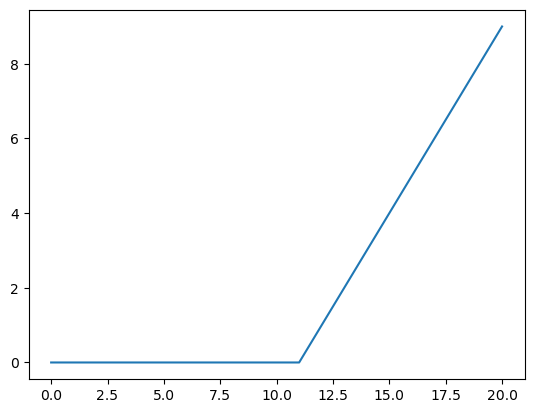

Forecast: 3.00 Capacity: 20.0


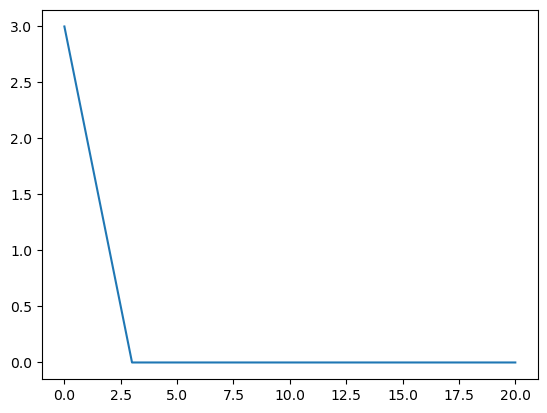

Forecast: -9.00 Capacity: 20.0


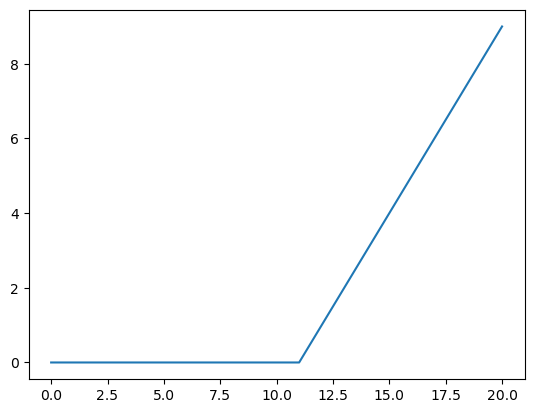

Forecast: -4.00 Capacity: 20.0


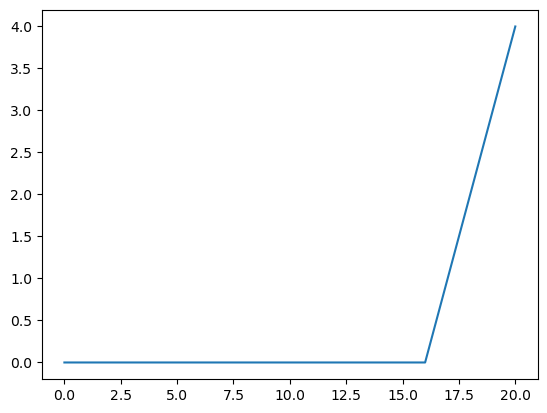

Forecast: 5.00 Capacity: 20.0


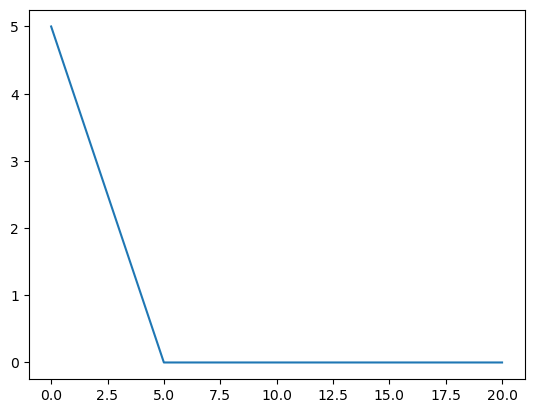

Forecast: -9.00 Capacity: 20.0


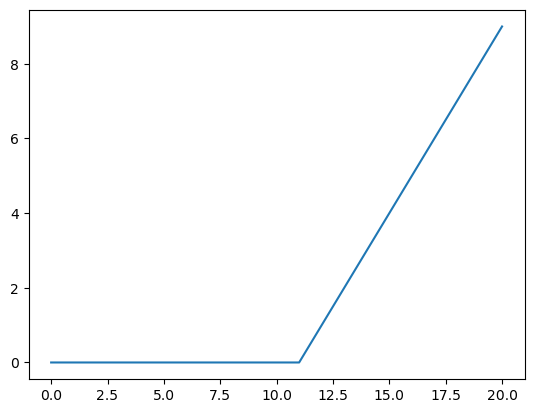

Forecast: -4.00 Capacity: 20.0


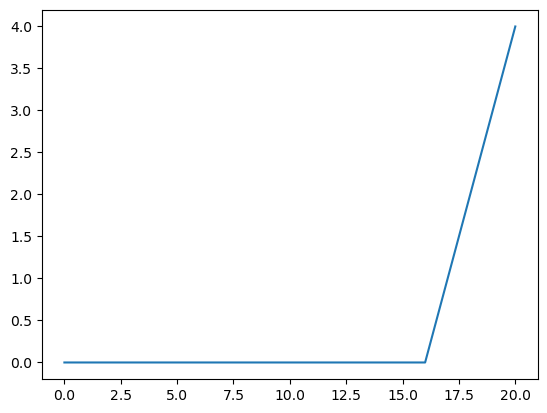

Forecast: -7.00 Capacity: 20.0


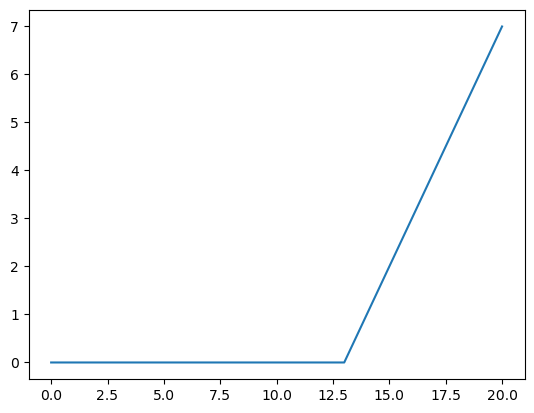

Forecast: -10.00 Capacity: 20.0


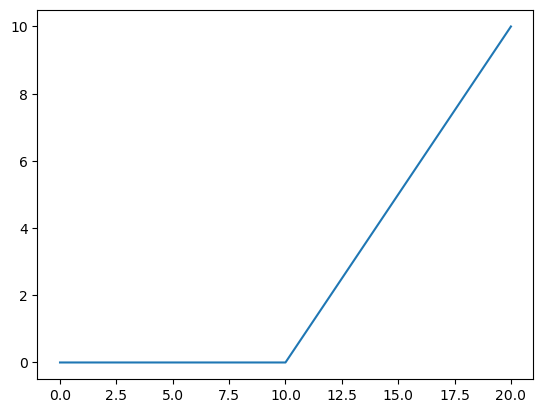

Forecast: -4.00 Capacity: 20.0


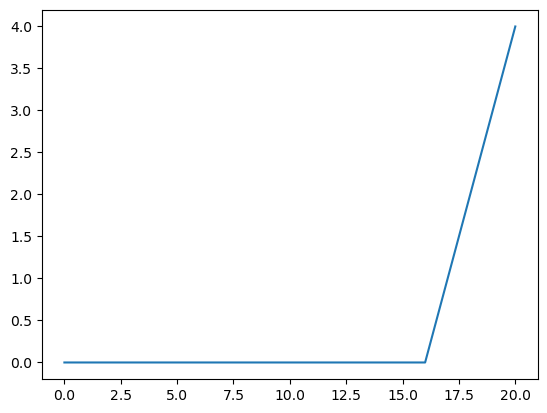

Forecast: 6.00 Capacity: 20.0


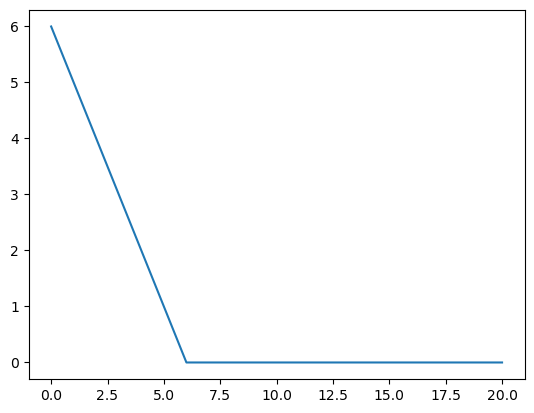

Forecast: -1.00 Capacity: 20.0


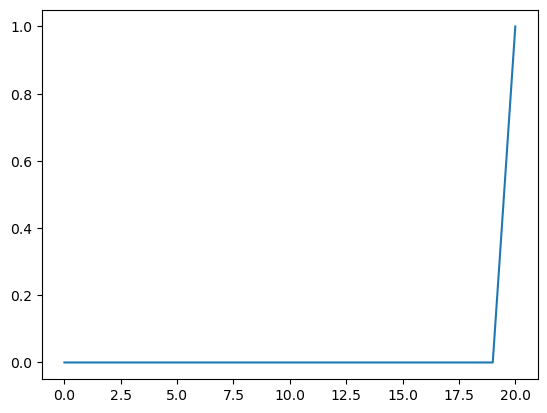

Forecast: -8.00 Capacity: 20.0


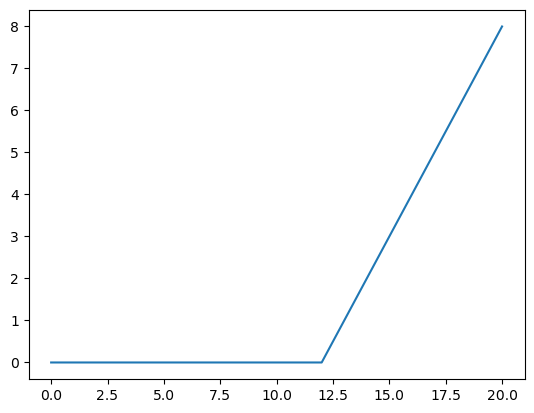

Forecast: 0.00 Capacity: 20.0


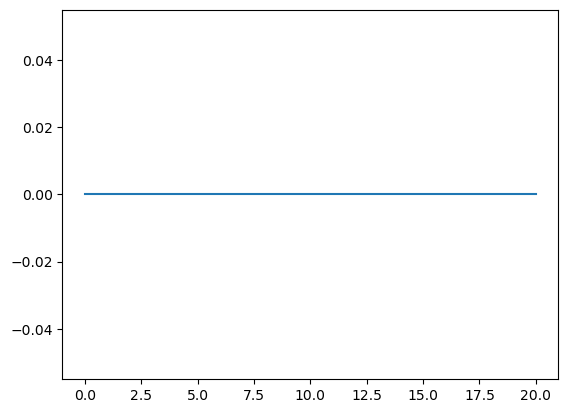

Forecast: -1.00 Capacity: 20.0


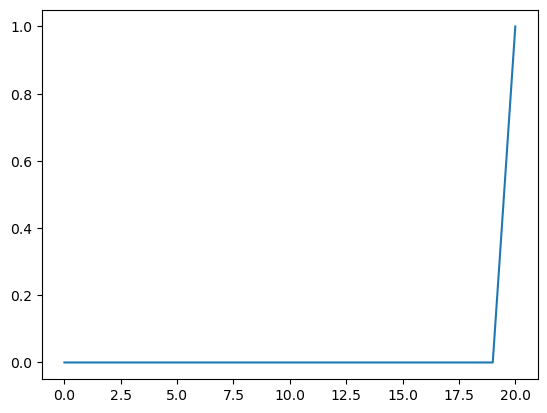

Forecast: 0.00 Capacity: 20.0


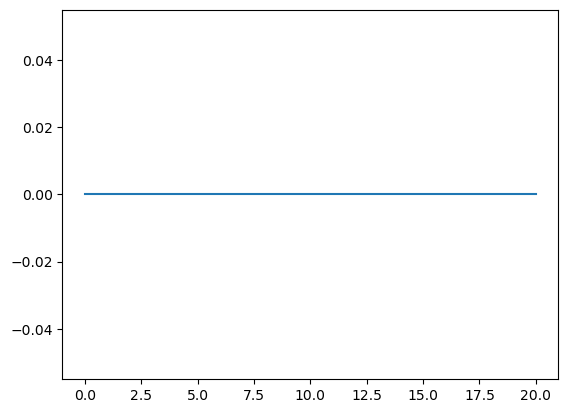

Forecast: -7.00 Capacity: 20.0


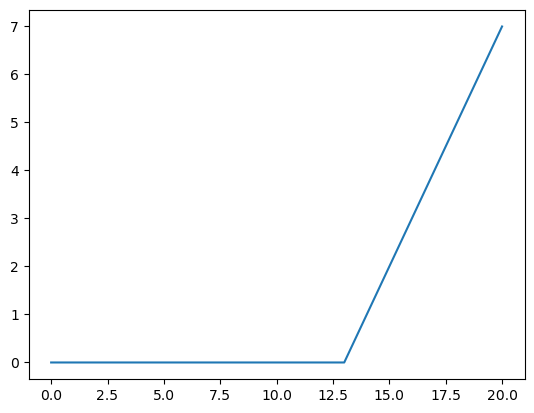

Forecast: -1.00 Capacity: 20.0


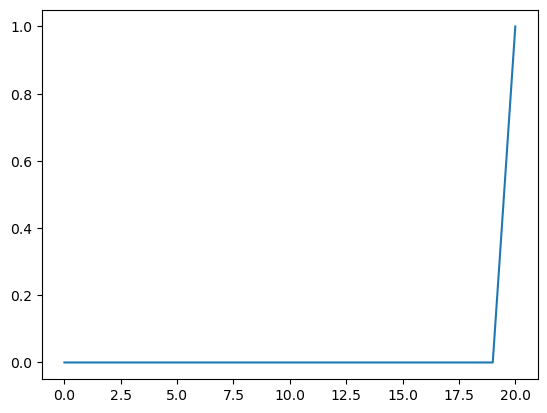

Forecast: 7.00 Capacity: 20.0


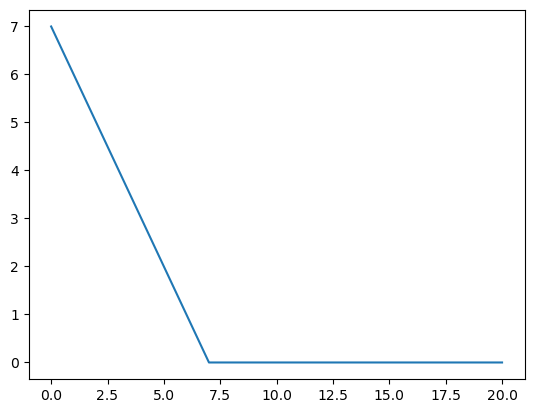

Forecast: 8.00 Capacity: 20.0


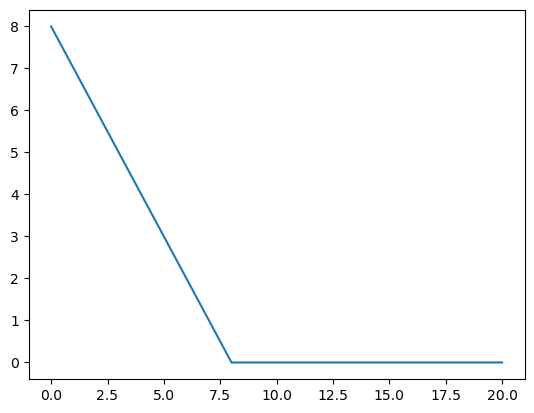

In [67]:
for idx in range(20):
    print(f'Forecast: {forecast[idx]:.2f} Capacity: {capacity[idx]}')
    plt.plot(costs[idx].detach().numpy())
    plt.show()